# Ноутбук 7 — Эксперимент 4: Абляционные исследования

**Назначение.** Три абляции:
1. **По модальностям** — eye-only / physio-only / combined.
2. **По каналам (drop-one)** — поочерёдное удаление одного канала.
3. **По типам статистик** — только {mean} / {mean+std} / все 9 моментов.

**Главный практический вывод:** на блочном уровне eye-only ≡ combined →
минимальный сенсорный стек = встроенный в HMD айтрекер.

In [1]:
import sys, time
from pathlib import Path

NB_ROOT = Path.cwd()
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from modules import config
from modules.experiments import (
    NON_FEATURE_COLS, add_per_subject_target,
    build_block_level_dataset, select_columns,
    run_window_loso_ablation, run_block_loso_ablation,
)

print(f"Notebooks root: {NB_ROOT}")

Notebooks root: D:\Programming\Python\Diplom\notebooks


## 7.1 Загрузка данных и подготовка датасетов

In [2]:
df = pd.read_csv(config.RESULTS_DIR / "feature_table.csv")
df = add_per_subject_target(df)
block = build_block_level_dataset(df)
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS
                and c != "arousal_class_persubj"]
block_all_cols = [c for c in block.columns
                  if c not in {"participant", "ssq_post_total",
                               "ssq_pre_total", "ssq_delta", "ssq_high"}]
print(f"Window-level: {df.shape}, признаков: {len(feature_cols)}")
print(f"Block-level:  {block.shape}, признаков: {len(block_all_cols)}")

Window-level: (15104, 157), признаков: 143


Block-level:  (32, 293), признаков: 288


## 7.2 Запуск всех абляций (либо загрузка готового CSV)

In [3]:
ABL_CSV = config.RESULTS_DIR / "exp04_ablation.csv"

if ABL_CSV.exists():
    print(f"Загружаю готовый результат: {ABL_CSV}")
    abl = pd.read_csv(ABL_CSV)
else:
    print("Запускаю абляции (~10 минут)...")
    results = []

    # Абляция 1 — модальности (window + block)
    for modality in ["eye", "physio", None]:
        tag = modality if modality else "combined"
        cols_w = select_columns(feature_cols, modality=modality)
        t0 = time.time()
        m_w = run_window_loso_ablation(df, cols_w)
        print(f"  [window RF] modality={tag:>8} n={m_w['n_features']:3} "
              f"acc={m_w['accuracy_mean']:.4f}  f1={m_w['f1_mean']:.4f} "
              f"({time.time()-t0:.1f} с)")
        results.append({"ablation": "modality", "level": "window",
                        "variant": tag, **m_w})
        cols_b = select_columns(block_all_cols, modality=modality)
        t0 = time.time()
        m_b = run_block_loso_ablation(block, cols_b)
        print(f"  [block XGB] modality={tag:>8} n={m_b['n_features']:3} "
              f"acc={m_b['accuracy_mean']:.4f}  f1={m_b['f1_mean']:.4f} "
              f"({time.time()-t0:.1f} с)")
        results.append({"ablation": "modality", "level": "block",
                        "variant": tag, **m_b})

    # Абляция 2 — drop-channel (window only)
    for ch in ["pupil", "gaze", "head", "eda", "hr", "skt", "bvp", "acc", "hrv"]:
        cols_w = select_columns(feature_cols, drop_channel=ch)
        t0 = time.time()
        m_w = run_window_loso_ablation(df, cols_w)
        print(f"  [window RF] -{ch:<5} n={m_w['n_features']:3} "
              f"acc={m_w['accuracy_mean']:.4f}  f1={m_w['f1_mean']:.4f} "
              f"({time.time()-t0:.1f} с)")
        results.append({"ablation": "drop_channel", "level": "window",
                        "variant": f"-{ch}", **m_w})

    # Абляция 3 — типы статистик
    for keep in ["mean", "mean_std", None]:
        tag = keep if keep else "all"
        cols_w = select_columns(feature_cols, keep_stat=keep)
        t0 = time.time()
        m_w = run_window_loso_ablation(df, cols_w)
        print(f"  [window RF] stats={tag:>8} n={m_w['n_features']:3} "
              f"acc={m_w['accuracy_mean']:.4f}  f1={m_w['f1_mean']:.4f} "
              f"({time.time()-t0:.1f} с)")
        results.append({"ablation": "stats", "level": "window",
                        "variant": tag, **m_w})

    abl = pd.DataFrame(results)
    abl.to_csv(ABL_CSV, index=False)
    print(f"\nСохранено: {ABL_CSV}")

print(f"Размер: {abl.shape}")
abl.head()

Загружаю готовый результат: D:\Programming\Python\Diplom\source\results\exp04_ablation.csv
Размер: (18, 10)


,ablation,level,variant,n_features,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_mean,auc_std
0,modality,window,eye,90,0.653535,0.060244,0.623263,0.064877,0.707813,0.076114
1,modality,block,eye,180,0.718750,0.000000,0.704615,0.000000,0.773810,0.000000
2,modality,window,physio,53,0.528933,0.087385,0.464002,0.059715,0.493764,0.089412
3,modality,block,physio,106,0.375000,0.000000,0.352227,0.000000,0.289683,0.000000
4,modality,window,combined,143,0.652609,0.066530,0.618928,0.070737,0.694481,0.081054


## 7.3 Абляция 1: по модальностям

In [4]:
modality = abl[abl["ablation"] == "modality"][
    ["level", "variant", "n_features", "accuracy_mean", "f1_mean", "auc_mean"]
].sort_values(["level", "variant"])
print(modality.to_string(index=False))

 level  variant  n_features  accuracy_mean  f1_mean  auc_mean
 block combined         288       0.718750 0.704615  0.738095
 block      eye         180       0.718750 0.704615  0.773810
 block   physio         106       0.375000 0.352227  0.289683
window combined         143       0.652609 0.618928  0.694481
window      eye          90       0.653535 0.623263  0.707813
window   physio          53       0.528933 0.464002  0.493764


**Главное наблюдение.** На блочном уровне `eye-only` и `combined` дают идентичную
accuracy = 0,7188; AUC у `eye-only` даже выше, чем у `combined`. Окуломоторика —
основной носитель сигнала о SSQ.

## 7.4 Абляция 2: по каналам (drop-one, оконный уровень RF)

In [5]:
base_f1 = float(abl.query("ablation == 'modality' and level == 'window' and variant == 'combined'")["f1_mean"].iloc[0])
drops = abl[abl["ablation"] == "drop_channel"][
    ["variant", "n_features", "accuracy_mean", "f1_mean"]
].copy()
drops["delta_f1_vs_combined"] = drops["f1_mean"] - base_f1
drops = drops.sort_values("f1_mean")
print(drops.to_string(index=False))

variant  n_features  accuracy_mean  f1_mean  delta_f1_vs_combined
 -pupil         107       0.623279 0.577490             -0.041438
  -head         116       0.642942 0.607008             -0.011920
   -acc         134       0.648570 0.615137             -0.003791
  -gaze         116       0.652741 0.617385             -0.001543
   -eda         132       0.652807 0.619718              0.000790
   -skt         133       0.653734 0.620234              0.001306
   -hrv         138       0.654727 0.620881              0.001953
    -hr         134       0.656449 0.623351              0.004423
   -bvp         134       0.661083 0.628942              0.010014


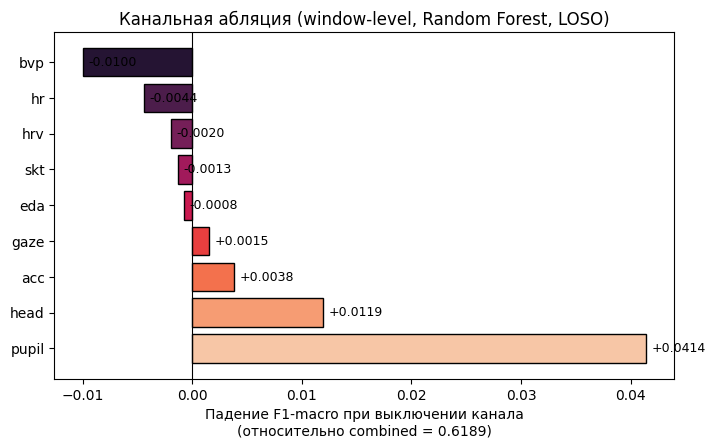

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sub = drops.copy()
sub["channel"] = sub["variant"].str.replace("-", "", regex=False)
sub = sub.sort_values("delta_f1_vs_combined")
colors = sns.color_palette("rocket_r", len(sub))
ax.barh(sub["channel"], -sub["delta_f1_vs_combined"], color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Падение F1-macro при выключении канала\n(относительно combined = {base_f1:.4f})")
ax.set_title("Канальная абляция (window-level, Random Forest, LOSO)")
for i, (_, row) in enumerate(sub.iterrows()):
    ax.text(-row["delta_f1_vs_combined"] + 0.0005, i,
            f"{-row['delta_f1_vs_combined']:+.4f}", va="center", fontsize=9)
fig_dir = config.RESULTS_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "fig11_channel_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

**Pupil — единственный канал, удаление которого критично снижает F1**
(ΔF1 = -0,0414). Удаление BVP/HR/EDA/SKT не ухудшает или даже немного улучшает
F1 — эти каналы вносят больше шума, чем сигнала.

## 7.5 Абляция 3: по типам статистик

In [7]:
stats = abl[abl["ablation"] == "stats"][
    ["variant", "n_features", "accuracy_mean", "f1_mean", "auc_mean"]
].sort_values("n_features")
print(stats.to_string(index=False))

 variant  n_features  accuracy_mean  f1_mean  auc_mean
    mean          15       0.642942 0.610103  0.679712
mean_std          30       0.645723 0.611563  0.681300
     all         143       0.652609 0.618928  0.694481


**Прирост от полного набора моментов мал** — {mean} даёт F1 = 0,6101, все
9 типов — F1 = 0,6189. Расширение в 9,5 раз даёт +0,9 п.п. F1.

## 7.6 Выводы

* Минимальный сенсорный стек для предсказания SSQ — встроенный в HMD айтрекер
  (pupil + gaze + head); носимая физиология практически не нужна.
* Pupil — единственный канал, отключение которого критично ухудшает качество.
* Простые статистики (mean, std) обеспечивают ≈99% производительности.